Loading AD Grad-CAM images...
Loading PD Grad-CAM images...
✅ Overlap analysis saved at: D:\GradCAM_overlap_output_v2\overlap_analysis.csv


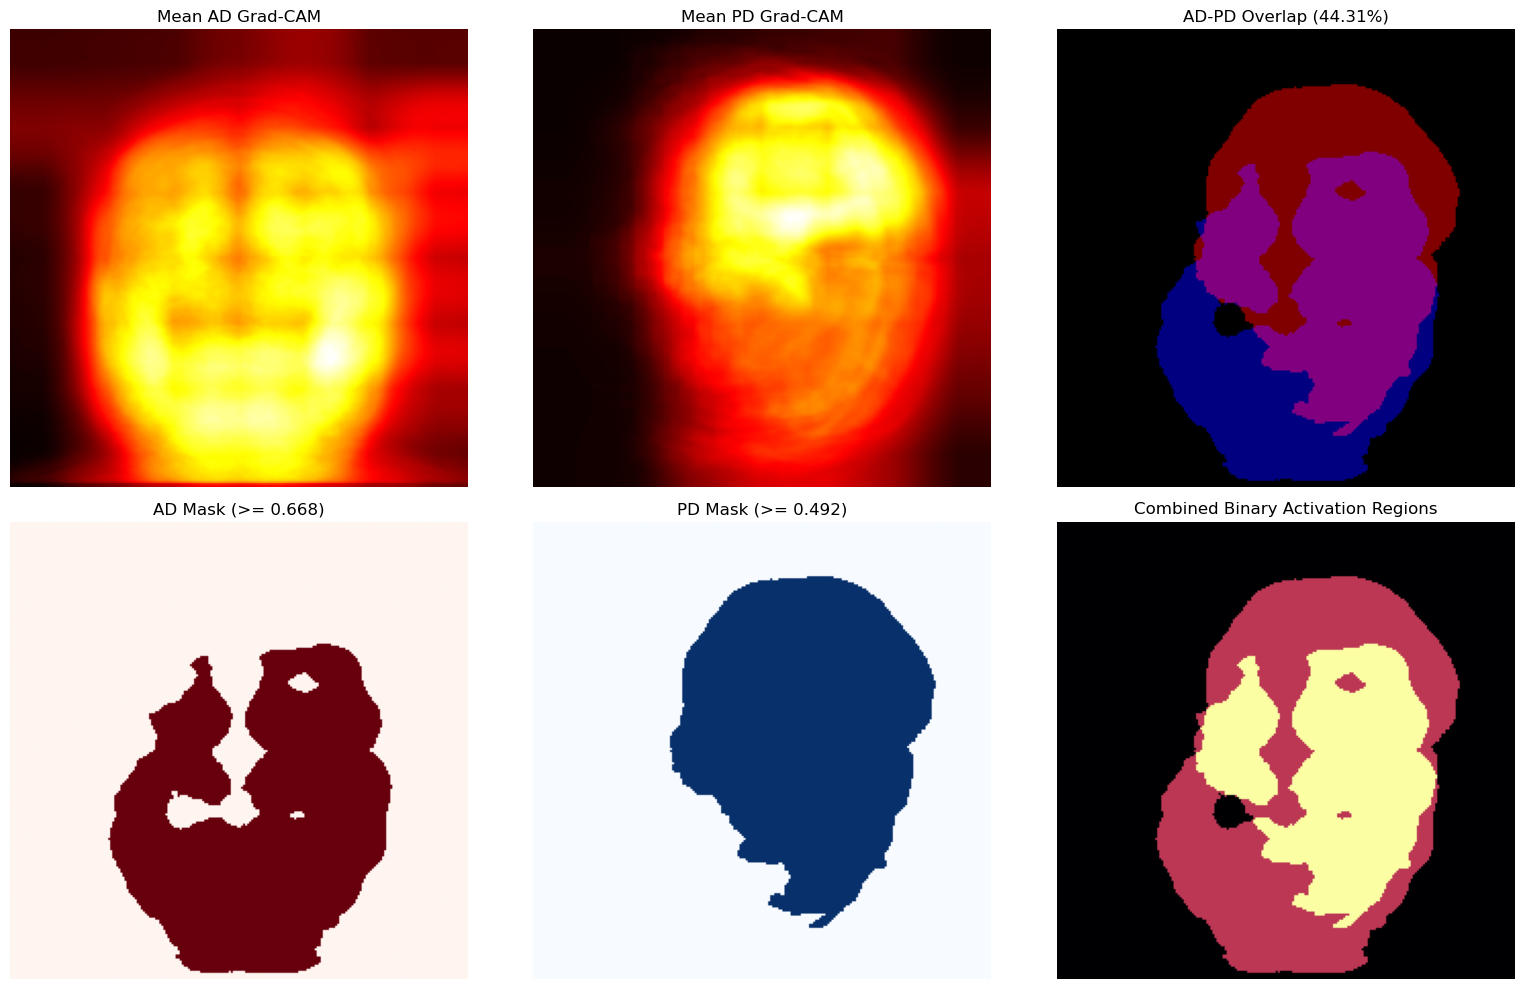

✅ Visualizations and results saved in: D:\GradCAM_overlap_output_v2


In [2]:
# ================================================================
# 📘 AD vs PD Grad-CAM Overlap Analysis (Improved Version)
# ================================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ================================================================
# 🔧 USER CONFIGURATION
# ================================================================
ad_path = r"D:\AD_gradcam_outputs"
pd_path = r"D:\PD_gradcam_outputs"
output_dir = r"D:\GradCAM_overlap_output_v2"

os.makedirs(output_dir, exist_ok=True)

target_size = (224, 224)

# ================================================================
# 🧩 Helper Functions
# ================================================================

def load_and_average_images(folder_path, target_size):
    """Load all images from folder, resize, normalize, and average."""
    images = []
    for fname in os.listdir(folder_path):
        if fname.lower().endswith((".png", ".jpg", ".jpeg")):
            img_path = os.path.join(folder_path, fname)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, target_size)
            img = img.astype(np.float32) / 255.0
            images.append(img)
    if len(images) == 0:
        raise ValueError(f"No images found in {folder_path}")
    avg_img = np.mean(images, axis=0)
    return avg_img

def normalize_image(img):
    """Normalize to 0-1 range."""
    return (img - img.min()) / (img.max() - img.min() + 1e-8)

def percentile_threshold(img, percentile=70):
    """Create binary mask from top activations."""
    thresh = np.percentile(img, percentile)
    return (img >= thresh).astype(np.uint8), thresh

def compute_overlap(ad_mask, pd_mask):
    """Compute intersection and union between two binary masks."""
    intersection = np.logical_and(ad_mask, pd_mask).sum()
    union = np.logical_or(ad_mask, pd_mask).sum()
    overlap_percent = (intersection / union) * 100 if union > 0 else 0
    return overlap_percent, intersection, union

# ================================================================
# 📥 Load and Average Grad-CAMs
# ================================================================
print("Loading AD Grad-CAM images...")
ad_mean = load_and_average_images(ad_path, target_size)

print("Loading PD Grad-CAM images...")
pd_mean = load_and_average_images(pd_path, target_size)

# ================================================================
# ⚙️ Normalize and Threshold
# ================================================================
ad_mean = normalize_image(ad_mean)
pd_mean = normalize_image(pd_mean)

ad_mask, ad_thresh = percentile_threshold(ad_mean, percentile=70)
pd_mask, pd_thresh = percentile_threshold(pd_mean, percentile=70)

overlap_percent, intersection, union = compute_overlap(ad_mask, pd_mask)

# ================================================================
# 💾 Save Analysis Results
# ================================================================
csv_path = os.path.join(output_dir, "overlap_analysis.csv")
df = pd.DataFrame([{
    "AD_images": len(os.listdir(ad_path)),
    "PD_images": len(os.listdir(pd_path)),
    "AD_threshold": ad_thresh,
    "PD_threshold": pd_thresh,
    "Intersection_pixels": intersection,
    "Union_pixels": union,
    "Overlap_percent": overlap_percent
}])
df.to_csv(csv_path, index=False)
print(f"✅ Overlap analysis saved at: {csv_path}")

# ================================================================
# 🎨 Visualization
# ================================================================

# Masks overlay visualization
ad_overlay = cv2.merge([ad_mask*255, np.zeros_like(ad_mask), np.zeros_like(ad_mask)])  # Red
pd_overlay = cv2.merge([np.zeros_like(pd_mask), np.zeros_like(pd_mask), pd_mask*255])  # Blue
overlap_overlay = cv2.addWeighted(ad_overlay, 0.5, pd_overlay, 0.5, 0)

# Save images
cv2.imwrite(os.path.join(output_dir, "AD_mean.png"), (ad_mean*255).astype(np.uint8))
cv2.imwrite(os.path.join(output_dir, "PD_mean.png"), (pd_mean*255).astype(np.uint8))
cv2.imwrite(os.path.join(output_dir, "AD_PD_overlap.png"), overlap_overlay)

# ================================================================
# 📊 Display All Visualizations
# ================================================================
plt.figure(figsize=(16,10))

plt.subplot(2,3,1)
plt.imshow(ad_mean, cmap='hot')
plt.title("Mean AD Grad-CAM")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(pd_mean, cmap='hot')
plt.title("Mean PD Grad-CAM")
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(overlap_overlay[..., ::-1])
plt.title(f"AD-PD Overlap ({overlap_percent:.2f}%)")
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(ad_mask, cmap='Reds')
plt.title(f"AD Mask (>= {ad_thresh:.3f})")
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(pd_mask, cmap='Blues')
plt.title(f"PD Mask (>= {pd_thresh:.3f})")
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(ad_mask + pd_mask, cmap='inferno')
plt.title("Combined Binary Activation Regions")
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"✅ Visualizations and results saved in: {output_dir}")


Loading from D:\PD_gradcam_outputs: 100%|██████████| 490/490 [00:01<00:00, 475.02it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.6].


AD-specific: 27.80%
PD-specific: 27.80%
Overlap: 44.39%


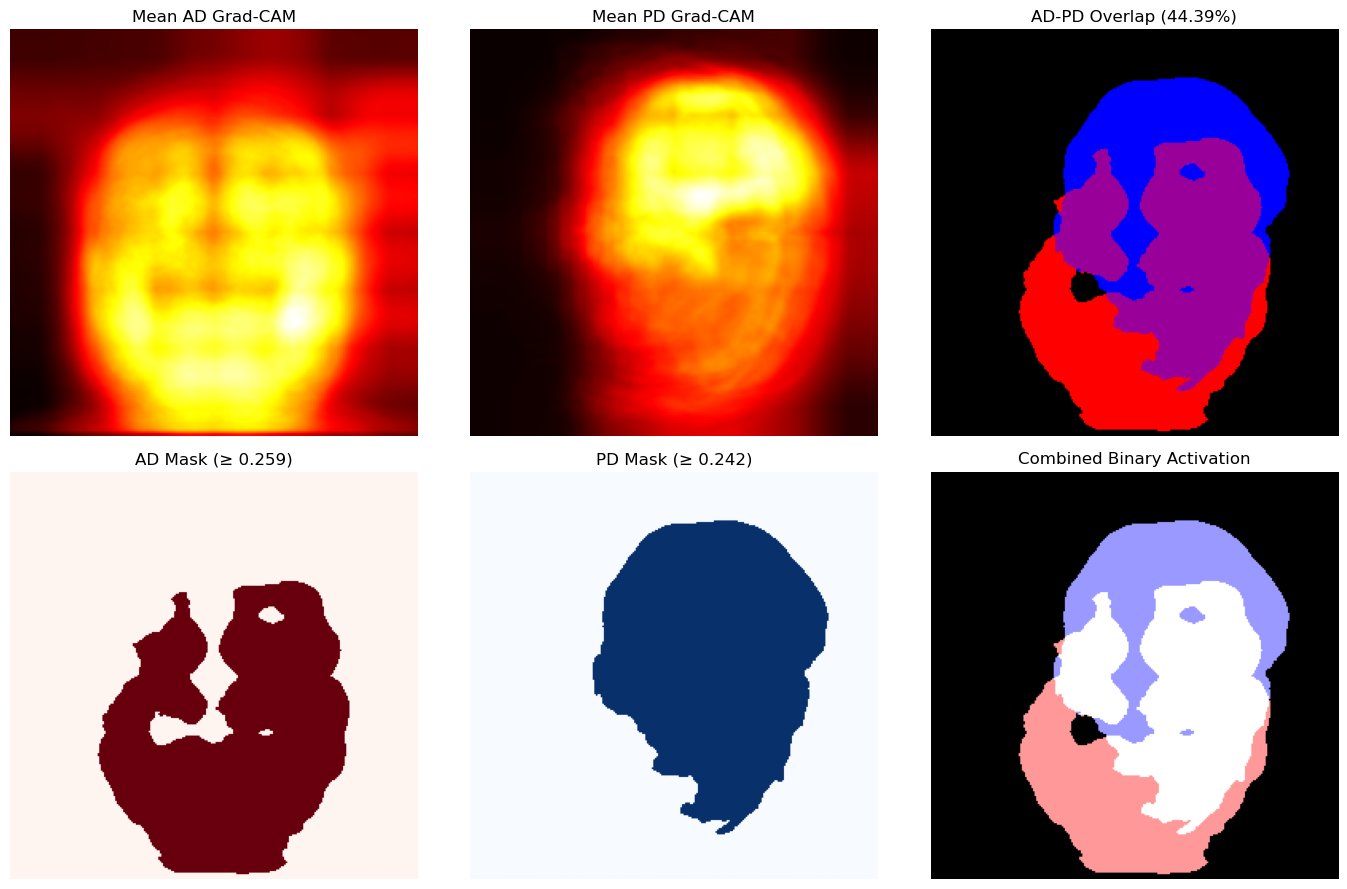

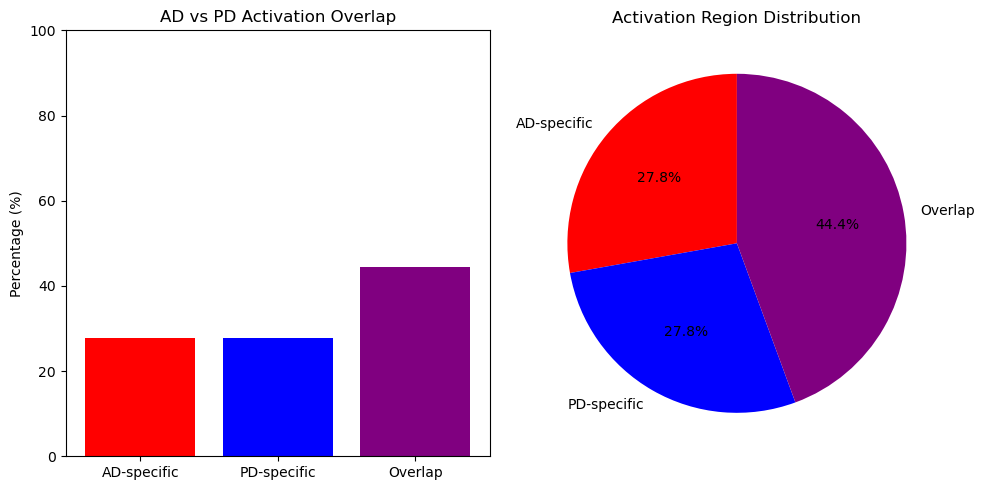

In [3]:
# ===============================
# AD vs PD Grad-CAM Overlap Analysis (Folder-Level)
# ===============================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# === Define paths ===
ad_folder = r"D:\AD_gradcam_outputs"
pd_folder = r"D:\PD_gradcam_outputs"

# === Helper function to load and normalize Grad-CAM images ===
def load_gradcam_images(folder, size=(256, 256)):
    images = []
    for file in tqdm(os.listdir(folder), desc=f"Loading from {folder}"):
        if file.lower().endswith(".png"):
            path = os.path.join(folder, file)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, size)
                img = img / 255.0
                images.append(img)
    if len(images) == 0:
        raise ValueError(f"No images found in {folder}")
    return np.stack(images)

# === Load all Grad-CAMs ===
ad_imgs = load_gradcam_images(ad_folder)
pd_imgs = load_gradcam_images(pd_folder)

# === Compute mean Grad-CAM for AD and PD ===
mean_ad = np.mean(ad_imgs, axis=0)
mean_pd = np.mean(pd_imgs, axis=0)

# === Compute binary activation masks (top 30% intensity) ===
ad_thresh = np.percentile(mean_ad, 70)
pd_thresh = np.percentile(mean_pd, 70)

ad_mask = mean_ad > ad_thresh
pd_mask = mean_pd > pd_thresh

# === Compute region statistics ===
overlap = np.logical_and(ad_mask, pd_mask)
ad_only = np.logical_and(ad_mask, ~pd_mask)
pd_only = np.logical_and(pd_mask, ~ad_mask)

ad_count = np.sum(ad_only)
pd_count = np.sum(pd_only)
overlap_count = np.sum(overlap)
total = ad_count + pd_count + overlap_count

ad_pct = 100 * ad_count / total
pd_pct = 100 * pd_count / total
overlap_pct = 100 * overlap_count / total

print(f"AD-specific: {ad_pct:.2f}%")
print(f"PD-specific: {pd_pct:.2f}%")
print(f"Overlap: {overlap_pct:.2f}%")

# === Visualization ===
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# Grad-CAM averages
axes[0,0].imshow(mean_ad, cmap='hot')
axes[0,0].set_title("Mean AD Grad-CAM")

axes[0,1].imshow(mean_pd, cmap='hot')
axes[0,1].set_title("Mean PD Grad-CAM")

# Overlap map
overlap_rgb = np.zeros((*ad_mask.shape, 3))
overlap_rgb[ad_only] = [1, 0, 0]     # Red: AD
overlap_rgb[pd_only] = [0, 0, 1]     # Blue: PD
overlap_rgb[overlap] = [0.6, 0, 0.6] # Purple: Overlap
axes[0,2].imshow(overlap_rgb)
axes[0,2].set_title(f"AD-PD Overlap ({overlap_pct:.2f}%)")

# Binary masks
axes[1,0].imshow(ad_mask, cmap='Reds')
axes[1,0].set_title(f"AD Mask (≥ {ad_thresh:.3f})")

axes[1,1].imshow(pd_mask, cmap='Blues')
axes[1,1].set_title(f"PD Mask (≥ {pd_thresh:.3f})")

# Combined binary activation map
combined_map = np.zeros_like(overlap_rgb)
combined_map[ad_mask] = [1, 0.6, 0.6]
combined_map[pd_mask] += [0.6, 0.6, 1]
axes[1,2].imshow(combined_map)
axes[1,2].set_title("Combined Binary Activation")

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

# === Summary Graphs (Bar + Pie) ===
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
categories = ['AD-specific', 'PD-specific', 'Overlap']
values = [ad_pct, pd_pct, overlap_pct]
colors = ['red', 'blue', 'purple']

# Bar chart
ax[0].bar(categories, values, color=colors)
ax[0].set_ylim(0, 100)
ax[0].set_ylabel('Percentage (%)')
ax[0].set_title('AD vs PD Activation Overlap')

# Pie chart
ax[1].pie(values, labels=categories, autopct='%1.1f%%', colors=colors, startangle=90)
ax[1].set_title('Activation Region Distribution')

plt.tight_layout()
plt.show()


Loading PD_gradcam_outputs: 100%|██████████| 490/490 [00:00<00:00, 789.99it/s]


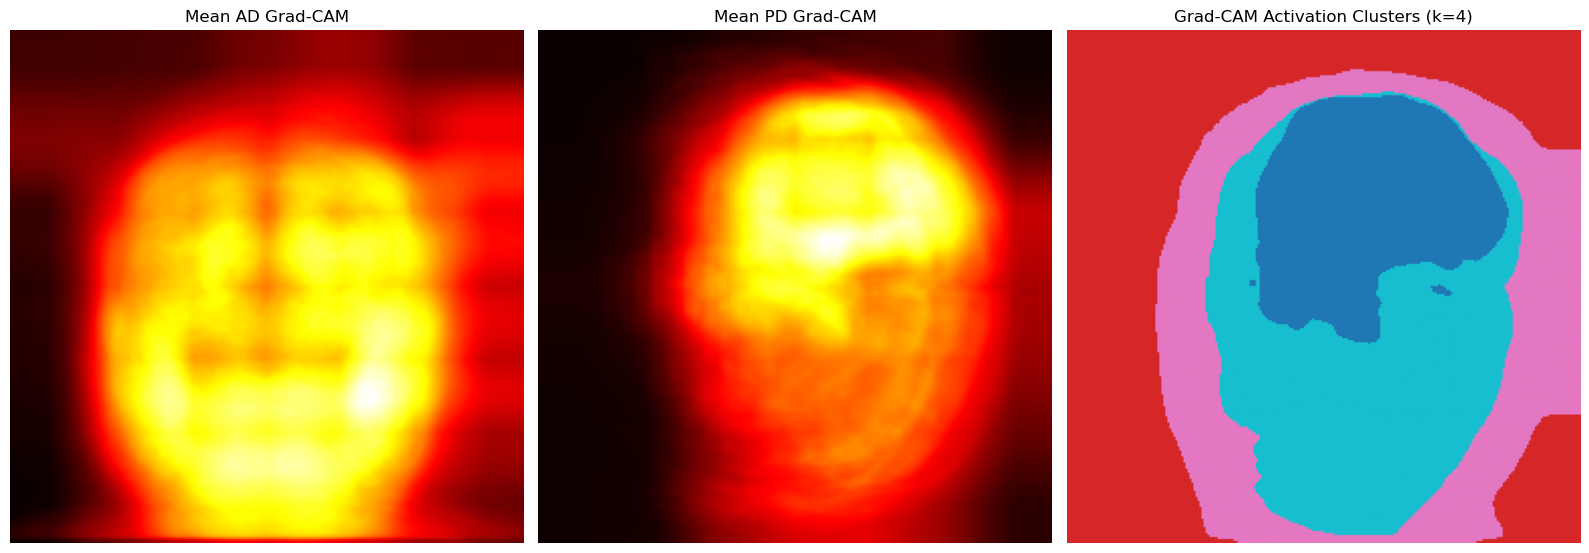

Cluster centroids (AD_intensity, PD_intensity):
Cluster 0: AD=0.244, PD=0.363
Cluster 1: AD=0.112, PD=0.049
Cluster 2: AD=0.199, PD=0.133
Cluster 3: AD=0.281, PD=0.239


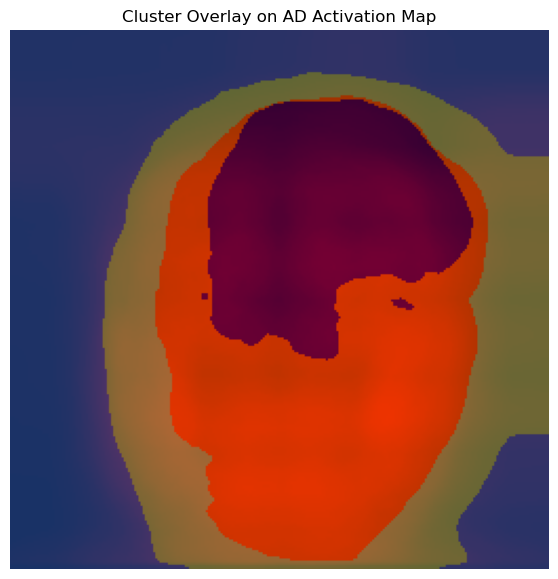

In [4]:
# ======================================
# AD vs PD Grad-CAM Cluster Visualization
# ======================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from tqdm import tqdm

# === Paths ===
ad_folder = r"D:\AD_gradcam_outputs"
pd_folder = r"D:\PD_gradcam_outputs"

# === Helper function ===
def load_and_average(folder, size=(256, 256)):
    imgs = []
    for file in tqdm(os.listdir(folder), desc=f"Loading {os.path.basename(folder)}"):
        if file.lower().endswith(".png"):
            path = os.path.join(folder, file)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, size)
                imgs.append(img / 255.0)
    return np.mean(imgs, axis=0)

# === Compute mean Grad-CAMs ===
mean_ad = load_and_average(ad_folder)
mean_pd = load_and_average(pd_folder)

# === Stack into a 2D feature array for clustering ===
h, w = mean_ad.shape
features = np.stack([mean_ad.flatten(), mean_pd.flatten()], axis=1)

# === Apply KMeans clustering ===
k = 4  # you can change this to 3 or 5 to explore different granularities
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(features)
cluster_map = clusters.reshape(h, w)

# === Visualize clusters ===
plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
plt.imshow(mean_ad, cmap='hot')
plt.title("Mean AD Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mean_pd, cmap='hot')
plt.title("Mean PD Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cluster_map, cmap='tab10')
plt.title(f"Grad-CAM Activation Clusters (k={k})")
plt.axis("off")

plt.tight_layout()
plt.show()

# === Optional: interpret cluster centroids ===
print("Cluster centroids (AD_intensity, PD_intensity):")
for i, c in enumerate(kmeans.cluster_centers_):
    print(f"Cluster {i}: AD={c[0]:.3f}, PD={c[1]:.3f}")

# === Overlay clusters on activation map ===
overlay = cv2.addWeighted(cv2.applyColorMap((mean_ad*255).astype(np.uint8), cv2.COLORMAP_HOT), 0.6,
                          cv2.applyColorMap((cluster_map*(255/k)).astype(np.uint8), cv2.COLORMAP_JET), 0.4, 0)

plt.figure(figsize=(7, 7))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Cluster Overlay on AD Activation Map")
plt.axis("off")
plt.show()


Loading PD_gradcam_outputs: 100%|██████████| 490/490 [00:00<00:00, 799.62it/s]


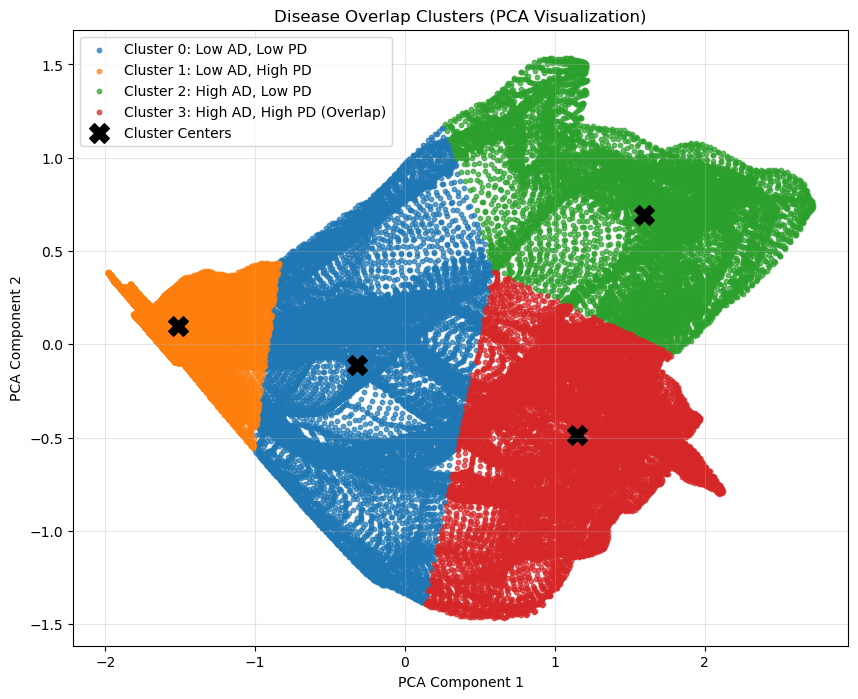


Cluster Centers in Original Feature Space:
Cluster 0: AD activation = -0.146, PD activation = -0.306
Cluster 1: AD activation = -1.139, PD activation = -1.004
Cluster 2: AD activation = 0.639, PD activation = 1.616
Cluster 3: AD activation = 1.157, PD activation = 0.469

PCA Explained Variance Ratio: [0.86232812 0.13767188]


In [5]:
# ==========================================
# PCA Visualization of AD-PD Grad-CAM Clusters
# ==========================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from tqdm import tqdm

# === Paths ===
ad_folder = r"D:\AD_gradcam_outputs"
pd_folder = r"D:\PD_gradcam_outputs"

# === Function to load and average Grad-CAMs ===
def load_and_average(folder, size=(256, 256)):
    imgs = []
    for file in tqdm(os.listdir(folder), desc=f"Loading {os.path.basename(folder)}"):
        if file.lower().endswith(".png"):
            path = os.path.join(folder, file)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, size)
                imgs.append(img / 255.0)
    return np.mean(imgs, axis=0)

# === Load Grad-CAM means ===
mean_ad = load_and_average(ad_folder)
mean_pd = load_and_average(pd_folder)

# === Prepare feature matrix ===
h, w = mean_ad.shape
features = np.stack([mean_ad.flatten(), mean_pd.flatten()], axis=1)

# === Normalize data ===
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# === KMeans clustering to find disease overlap patterns ===
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

# === PCA for visualization ===
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

# === Combine into dataframe-like structure ===
ad_values = mean_ad.flatten()
pd_values = mean_pd.flatten()

# === Plot PCA clusters ===
plt.figure(figsize=(10, 8))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
labels = [
    "Cluster 0: Low AD, Low PD",
    "Cluster 1: Low AD, High PD",
    "Cluster 2: High AD, Low PD",
    "Cluster 3: High AD, High PD (Overlap)"
]

for i in range(4):
    mask = clusters == i
    plt.scatter(pca_features[mask, 0], pca_features[mask, 1], s=10, alpha=0.7, color=colors[i], label=labels[i])

# Cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], s=200, color='black', marker='X', label='Cluster Centers')

plt.title("Disease Overlap Clusters (PCA Visualization)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# === Print cluster center values (AD vs PD activation averages) ===
print("\nCluster Centers in Original Feature Space:")
for i, c in enumerate(kmeans.cluster_centers_):
    print(f"Cluster {i}: AD activation = {c[0]:.3f}, PD activation = {c[1]:.3f}")

# === Explained variance ratio ===
print("\nPCA Explained Variance Ratio:", pca.explained_variance_ratio_)
